# Exploratory Data Analysis and Visualization

### import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load cleaned data
df = pd.read_csv("california_housing_cleaned.csv")

### Univariate Analysis (Distribution of House Values)

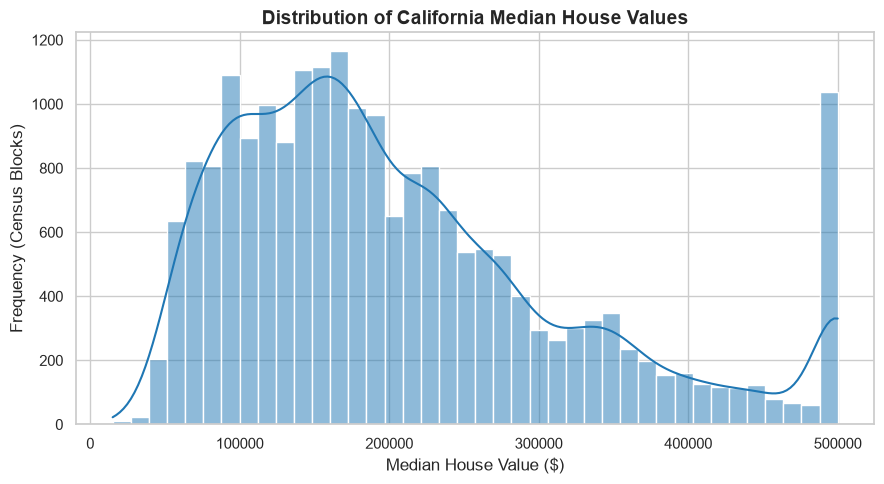

In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(df["median_house_value"], kde=True, bins=40, color="#1f77b4")
plt.title("Distribution of California Median House Values", fontsize=14, weight="bold")
plt.xlabel("Median House Value ($)", fontsize=12)
plt.ylabel("Frequency (Census Blocks)", fontsize=12)
plt.tight_layout()
plt.savefig("eda_target_distribution.png", dpi=300)
plt.show()

### Bivariate Analysis (Median Income vs. House Value)

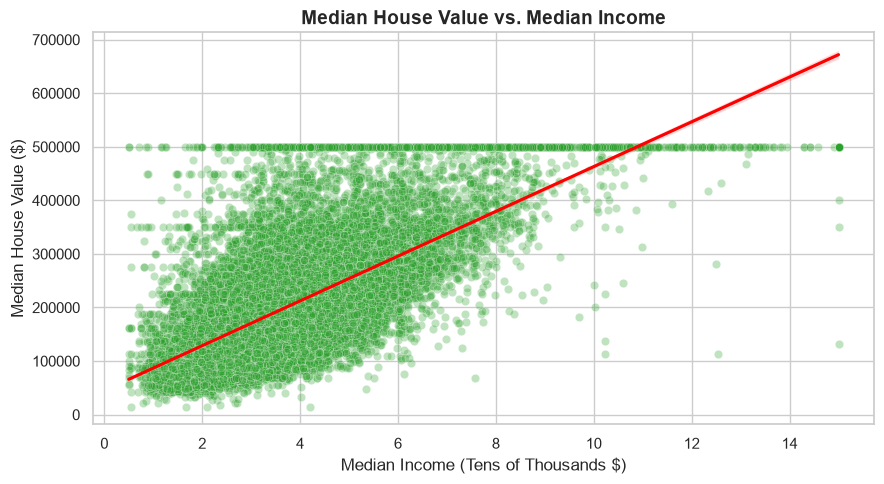

In [5]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="median_income", y="median_house_value", data=df, alpha=0.3, color="#2ca02c")
sns.regplot(x="median_income", y="median_house_value", data=df, scatter=False, color="red")
plt.title("Median House Value vs. Median Income", fontsize=14, weight="bold")
plt.xlabel("Median Income (Tens of Thousands $)", fontsize=12)
plt.ylabel("Median House Value ($)", fontsize=12)
plt.tight_layout()
plt.savefig("eda_income_vs_price.png", dpi=300)
plt.show()

### Spatial Trend Analysis (Latitude & Longitude Price Mapping)

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    x=df["longitude"],
    y=df["latitude"],
    c=df["median_house_value"],
    cmap="coolwarm",
    alpha=0.4,
    s=df["population"] / 100
)
plt.colorbar(scatter, label="Median House Value ($)")
plt.title("Spatial Geographic Distribution of California Housing Prices", fontsize=14, weight="bold")
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.tight_layout()
plt.savefig("eda_spatial_price_map.png", dpi=300)
plt.show()

### Multivariate Correlation Analysis

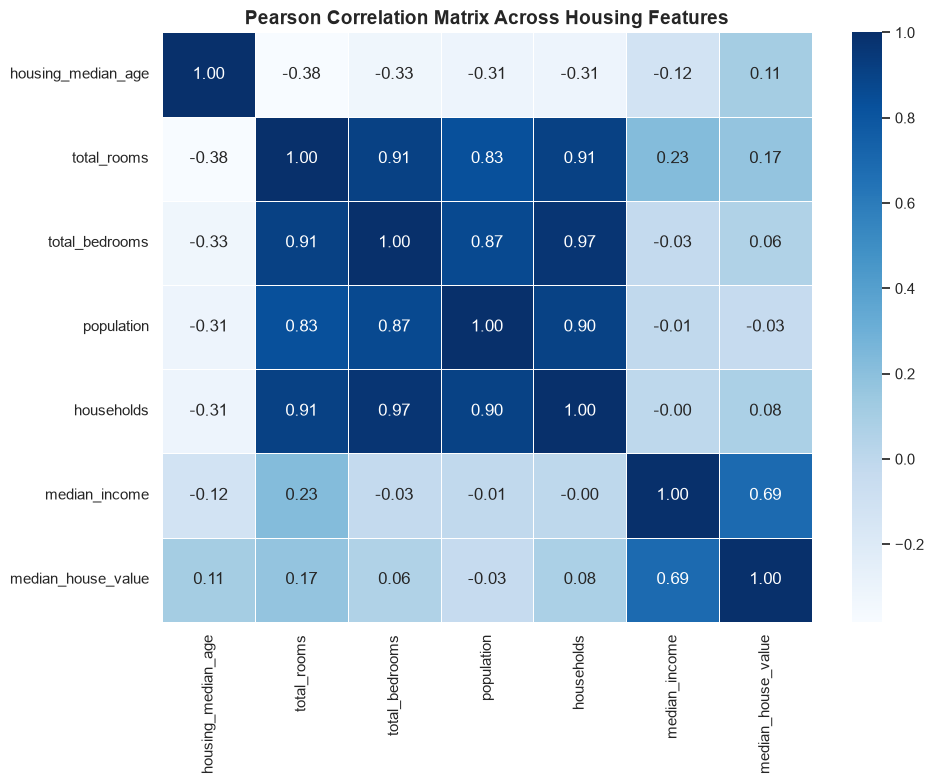

In [6]:
plt.figure(figsize=(10, 8))
numeric_cols = [
    "housing_median_age", "total_rooms", "total_bedrooms", 
    "population", "households", "median_income", "median_house_value"
]
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix Across Housing Features", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=300)
plt.show()

### Feature Engineering and Verification

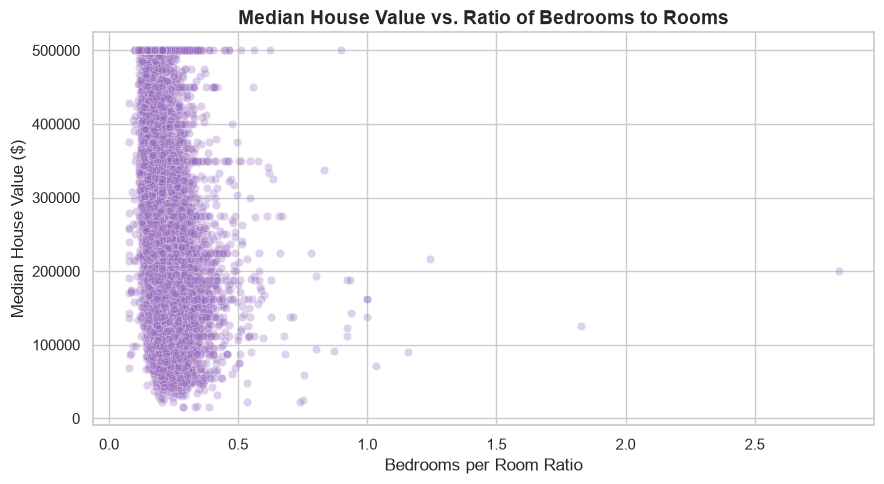

In [7]:
# Engineer derived attributes to isolate density effects from aggregate district counts
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

plt.figure(figsize=(9, 5))
sns.scatterplot(x="bedrooms_per_room", y="median_house_value", data=df, alpha=0.3, color="#9467bd")
plt.title("Median House Value vs. Ratio of Bedrooms to Rooms", fontsize=14, weight="bold")
plt.xlabel("Bedrooms per Room Ratio", fontsize=12)
plt.ylabel("Median House Value ($)", fontsize=12)
plt.tight_layout()
plt.savefig("eda_bedrooms_ratio.png", dpi=300)
plt.show()